### Pacotes importados

In [1]:
import Pkg

for pacote in ["Plots"]
    try
        @eval using $(Symbol(pacote))
    catch
        Pkg.add(pacote)
        @eval using $(Symbol(pacote))
    end
end

using LinearAlgebra
gr()

Plots.GRBackend()

## Chapter 11: Descent methods and line search

### Algorithm 11.2: Initialization of the exact line search 

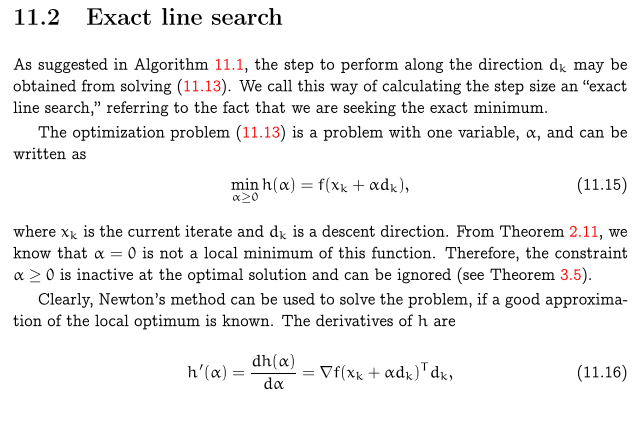

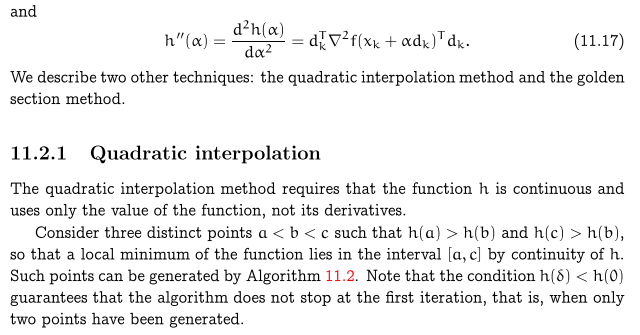

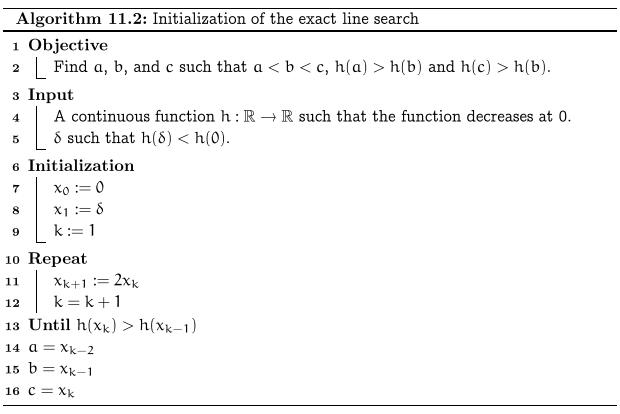

Test with Example 11.3: $h(x) = (2+x) \cos(2+x)$.

Resultado do Algorithm 11.2
a = 0.8    h(a) = -2.6382225538722426
b = 1.6    h(b) = -3.228330298802929
c = 3.2    h(c) = 2.436286690761961

Verificação:
a < b < c ? true
h(a) > h(b) ? true
h(c) > h(b) ? true


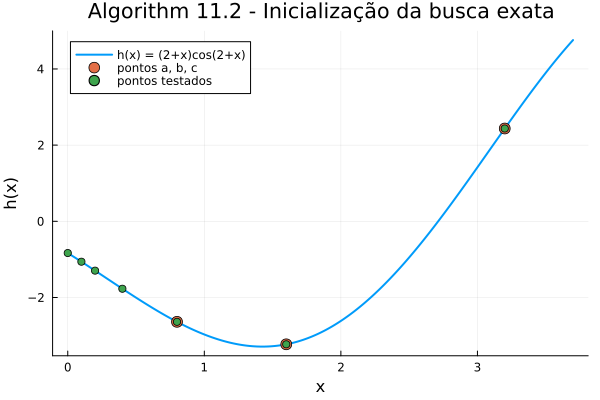

In [2]:
function inicializacao_busca_exata(h, δ; max_iter=100)
    x0 = 0.0
    x1 = δ

    
    if !(h(x1) < h(x0))
        error("A condição h(δ) < h(0) não foi satisfeita. Escolha outro δ.")
    end

    xs = [x0, x1]
    k = 1

    while k < max_iter
        xnovo = 2 * xs[end]
        push!(xs, xnovo)

        
        if h(xs[end]) > h(xs[end-1])
            a = xs[end-2]
            b = xs[end-1]
            c = xs[end]
            return a, b, c, xs
        end

        k += 1
    end

    error("Número máximo de iterações atingido.")
end


h(x) = (2 + x) * cos(2 + x)
δ = 0.1

a, b, c, xs = inicializacao_busca_exata(h, δ)

println("Resultado do Algorithm 11.2")
println("a = ", a, "    h(a) = ", h(a))
println("b = ", b, "    h(b) = ", h(b))
println("c = ", c, "    h(c) = ", h(c))
println()
println("Verificação:")
println("a < b < c ? ", a < b < c)
println("h(a) > h(b) ? ", h(a) > h(b))
println("h(c) > h(b) ? ", h(c) > h(b))


xplot = range(0, c + 0.5, length=400)

plot(xplot, h.(xplot),
     label="h(x) = (2+x)cos(2+x)",
     xlabel="x",
     ylabel="h(x)",
     title="Algorithm 11.2 - Inicialização da busca exata",
     linewidth=2)

scatter!([a, b, c], [h(a), h(b), h(c)],
         label="pontos a, b, c",
         markersize=6)

scatter!(xs, h.(xs),
         label="pontos testados",
         marker=:circle)


### Algorithm 11.3: Exact line search: quadratic interpolation

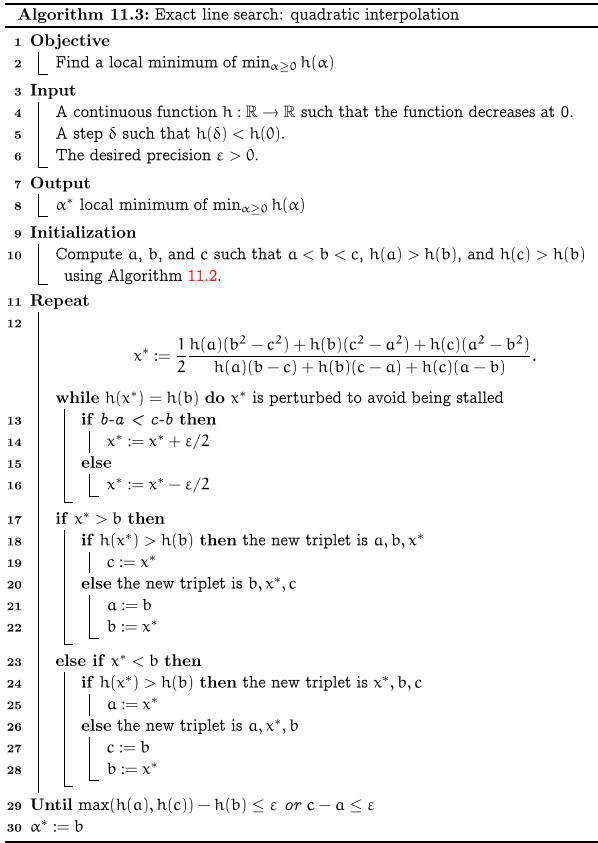

Test with Example 11.3: $h(x) = (2+x) \cos(2+x)$.

Resultado do Algorithm 11.3
α* = 1.4256188628382103
h(α*) = -3.2883713955905836
número de iterações = 9


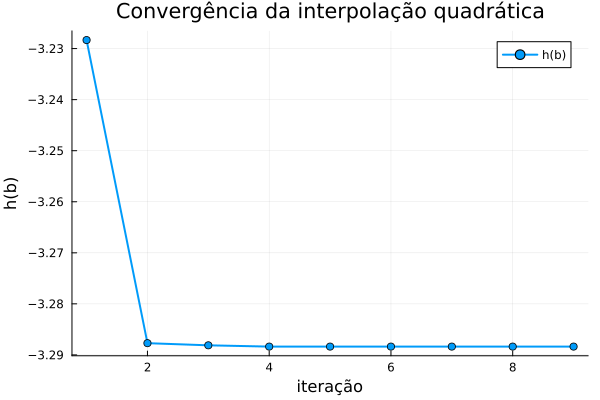

In [3]:
function busca_exata_interpolacao_quadratica(h, δ; ε=1e-6, max_iter=100)
    a, b, c, xs_init = inicializacao_busca_exata(h, δ)

    historico = [(a, b, c, h(a), h(b), h(c))]
    xstar = b

    for iter in 1:max_iter
        ha = h(a)
        hb = h(b)
        hc = h(c)

        numerador = ha*(b^2 - c^2) + hb*(c^2 - a^2) + hc*(a^2 - b^2)
        denominador = ha*(b - c) + hb*(c - a) + hc*(a - b)

        if abs(denominador) < eps()
            break
        end

        xstar = 0.5 * numerador / denominador

        
        if isapprox(h(xstar), hb; atol=ε, rtol=ε)
            if (b - a) < (c - b)
                xstar += ε / 2
            else
                xstar -= ε / 2
            end
        end

        hx = h(xstar)

        if xstar > b
            if hx > hb
                c = xstar
            else
                a = b
                b = xstar
            end
        elseif xstar < b
            if hx > hb
                a = xstar
            else
                c = b
                b = xstar
            end
        else
            break
        end

        push!(historico, (a, b, c, h(a), h(b), h(c)))

        if maximum([h(a), h(c)]) - h(b) <= ε || c - a <= ε
            break
        end
    end

    αstar = b
    return αstar, h(αstar), historico
end


h(x) = (2 + x) * cos(2 + x)
δ = 0.1
ε = 1e-6

αstar, hmin, historico = busca_exata_interpolacao_quadratica(h, δ; ε=ε)

println("Resultado do Algorithm 11.3")
println("α* = ", αstar)
println("h(α*) = ", hmin)
println("número de iterações = ", length(historico))


xplot = range(0, 3, length=500)

plot(xplot, h.(xplot),
     label="h(x)",
     xlabel="x",
     ylabel="h(x)",
     title="Algorithm 11.3 - Interpolação quadrática",
     linewidth=2)

scatter!([αstar], [hmin],
         label="mínimo encontrado",
         markersize=7)


valores_hb = [item[5] for item in historico]

plot(1:length(valores_hb), valores_hb,
     label="h(b)",
     xlabel="iteração",
     ylabel="h(b)",
     title="Convergência da interpolação quadrática",
     marker=:circle,
     linewidth=2)


### Algorithm 11.5: Line search

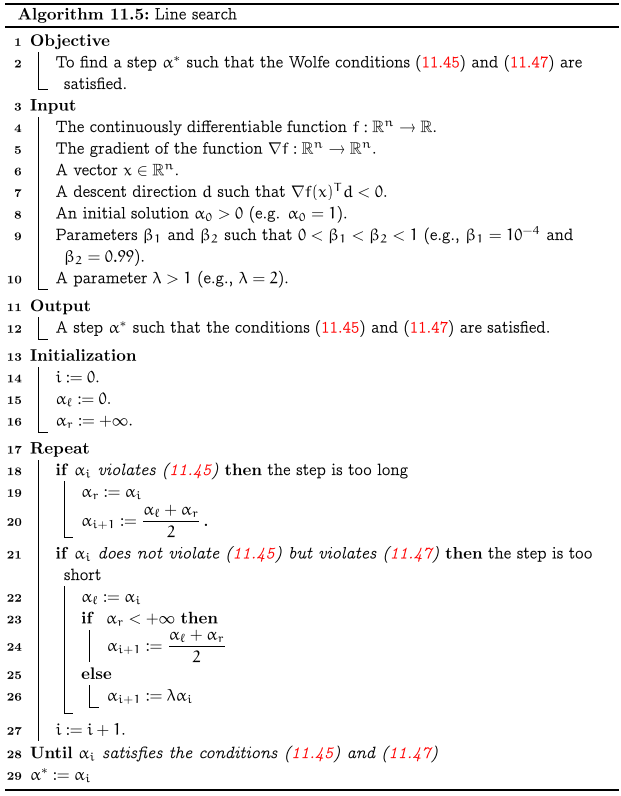

Example 11.2: $f(x) = \frac{1}{2} x_1^2 + \frac{9}{2} x_2^2$.

Resultado do Algorithm 11.5
x0 = [9.0, 1.0]
d0 = [-9.0, -9.0]
α* = 0.25
x0 + α*d = [6.75, -1.25]
f(x0) = 45.0
f(x0 + α*d) = 29.8125
histórico dos α testados = [1.0, 0.5, 0.25]


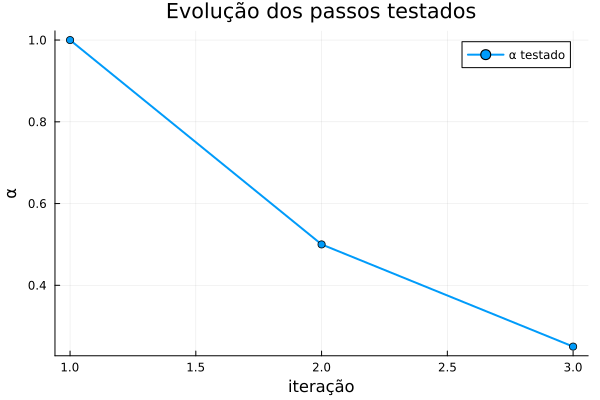

In [4]:
function line_search_wolfe(f, gradf, x, d;
                           α0=1.0, β1=1e-4, β2=0.99,
                           λ=2.0, max_iter=100)
    α = α0
    αl = 0.0
    αr = Inf

    fx = f(x)
    gx = gradf(x)
    gtd = dot(gx, d)

    if !(gtd < 0)
        error("d não é uma direção de descida, pois ∇f(x)'d não é negativo.")
    end

    historico = Float64[]

    for i in 1:max_iter
        push!(historico, α)

        armijo = f(x + α*d) <= fx + β1*α*gtd
        curvatura = dot(gradf(x + α*d), d) >= β2*gtd

        if armijo && curvatura
            return α, historico
        end

        if !armijo
            # passo muito longo
            αr = α
            α = (αl + αr) / 2
        else
            # passo muito curto
            αl = α
            if isfinite(αr)
                α = (αl + αr) / 2
            else
                α = λ * α
            end
        end
    end

    return α, historico
end

# Example 11.2
f_quad(x) = 0.5*x[1]^2 + 4.5*x[2]^2
grad_quad(x) = [x[1], 9.0*x[2]]

x0 = [9.0, 1.0]
d0 = -grad_quad(x0)

αstar, hist_α = line_search_wolfe(f_quad, grad_quad, x0, d0;
                                  α0=1.0, β1=1e-4, β2=0.99, λ=2.0)

xnovo = x0 + αstar*d0

println("Resultado do Algorithm 11.5")
println("x0 = ", x0)
println("d0 = ", d0)
println("α* = ", αstar)
println("x0 + α*d = ", xnovo)
println("f(x0) = ", f_quad(x0))
println("f(x0 + α*d) = ", f_quad(xnovo))
println("histórico dos α testados = ", hist_α)

# Plot do valor de f ao longo da direção de busca
αplot = range(0, 2αstar + 0.2, length=300)
φ = [f_quad(x0 + α*d0) for α in αplot]

plot(αplot, φ,
     label="f(x0 + αd)",
     xlabel="α",
     ylabel="f(x0 + αd)",
     title="Algorithm 11.5 - Line search",
     linewidth=2)

scatter!([αstar], [f_quad(xnovo)],
         label="α encontrado",
         markersize=7)

# Plot dos α testados durante a busca
plot(1:length(hist_α), hist_α,
     label="α testado",
     xlabel="iteração",
     ylabel="α",
     title="Evolução dos passos testados",
     marker=:circle,
     linewidth=2)


### Algorithm 11.6: Steepest descent

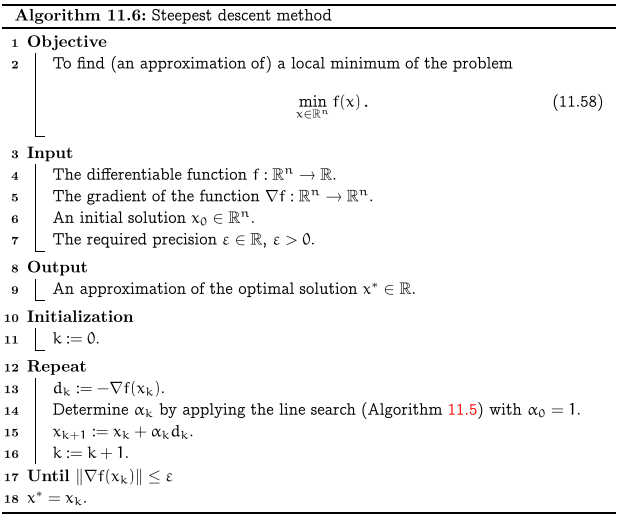

Test in the Rosenbrock function

In [5]:
unction steepest_descent(f, gradf, x0;
                          ε=1e-6, max_iter=10_000,
                          α0=1.0, β1=1e-4, β2=0.99, λ=2.0)
    x = copy(x0)
    trajetoria = [copy(x)]
    valores_f = [f(x)]
    normas_grad = [norm(gradf(x))]
    alphas = Float64[]

    k = 0

    while norm(gradf(x)) > ε && k < max_iter
        d = -gradf(x)

        α, _ = line_search_wolfe(f, gradf, x, d;
                                 α0=α0, β1=β1, β2=β2, λ=λ)

        x = x + α*d

        push!(trajetoria, copy(x))
        push!(valores_f, f(x))
        push!(normas_grad, norm(gradf(x)))
        push!(alphas, α)

        k += 1
    end

    return x, f(x), k, trajetoria, valores_f, normas_grad, alphas
end


f_rosen(x) = (1.0 - x[1])^2 + 100.0*(x[2] - x[1]^2)^2

function grad_rosen(x)
    dx1 = -2.0*(1.0 - x[1]) - 400.0*x[1]*(x[2] - x[1]^2)
    dx2 = 200.0*(x[2] - x[1]^2)
    return [dx1, dx2]
end

x0 = [-1.2, 1.0]
ε = 1e-6

xstar, fstar, k, trajetoria, valores_f, normas_grad, alphas =
    steepest_descent(f_rosen, grad_rosen, x0; ε=ε, max_iter=10_000)

println("Resultado do Algorithm 11.6")
println("x0 = ", x0)
println("x* ≈ ", xstar)
println("f(x*) ≈ ", fstar)
println("número de iterações = ", k)
println("norma do gradiente final = ", norm(grad_rosen(xstar)))


xs1 = [p[1] for p in trajetoria]
xs2 = [p[2] for p in trajetoria]


x1_grid = range(-1.5, 1.5, length=250)
x2_grid = range(-0.5, 2.0, length=250)

z = [f_rosen([x1, x2]) for x2 in x2_grid, x1 in x1_grid]

contour(x1_grid, x2_grid, z,
        levels=[0.1, 1, 5, 10, 50, 100, 250, 500],
        xlabel="x₁",
        ylabel="x₂",
        title="Steepest descent na função de Rosenbrock",
        label="curvas de nível")

plot!(xs1, xs2,
      label="trajetória",
      marker=:circle,
      linewidth=2)

scatter!([1.0], [1.0],
         label="mínimo real (1,1)",
         markersize=7)


plot(0:length(valores_f)-1, valores_f,
     label="f(xk)",
     xlabel="iteração k",
     ylabel="f(xk)",
     title="Convergência de f(xk)",
     yscale=:log10,
     marker=:circle,
     linewidth=2)


plot(0:length(normas_grad)-1, normas_grad,
     label="||∇f(xk)||",
     xlabel="iteração k",
     ylabel="norma do gradiente",
     title="Convergência da norma do gradiente",
     yscale=:log10,
     marker=:circle,
     linewidth=2)


UndefVarError: UndefVarError: `unction` not defined in `Main`
Suggestion: check for spelling errors or missing imports.